In [1]:
import pandas as pd
import numpy as np

import re
from bs4 import BeautifulSoup

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.preprocessing import LabelEncoder

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

# Save model
import joblib

In [2]:
cluster_data=pd.read_csv(r"D:\my projects\FixFlow-\notebooks\data\cluster_data.csv")
cluster_data.head()

,tags,answer_count,score,creation_date,question_id,title,body,AllAnswers,Text_Tags,All_Text,cluster,embedding,cluster_name
0,"['android', 'android-studio', 'kotlin']",55,190,1970-01-01 00:00:01.589490945,61807520,How to fix ERROR: No signature of method: buil...,<p>ERROR: No signature of method: build_ap86oa...,"[{'_id': ObjectId('69c530e7ce4825bba74fab32'),...",and the Tags: 'android' and 'android-studio' a...,How to fix ERROR: No signature of method: buil...,16,[10.079775 5.5477796 2.9399583 5.355781...,Java Gradle Build
1,"['android', 'google-play', 'android-manifest',...",7,190,1970-01-01 00:00:01.658868456,73129574,You can&#39;t submit updates as some informati...,<p>I cannot update my app in Google Play since...,"[{'_id': ObjectId('69c530e7ce4825bba74fab50'),...",and the Tags: 'android' and 'google-play' and ...,You can't submit updates as some information a...,16,[10.139143 5.907139 3.0050306 5.658852 ...,Java Gradle Build
2,"['mysql', 'svn']",15,189,1970-01-01 00:00:01.218228602,6371,"How do you manage databases in development, te...",<p>I've had a hard time trying to find good ex...,"[{'_id': ObjectId('69c530e7ce4825bba74fab57'),...",and the Tags: 'mysql' and 'svn',"How do you manage databases in development, te...",1,[11.3339615 2.5705624 2.3808308 4.036007 ...,PostgreSQL Database Cloning
3,"['linq', 'linq-to-sql', 'linq-to-entities', 'l...",9,189,1970-01-01 00:00:01.219157443,16322,Learning about LINQ,<h2>Overview</h2>\n<p>One of the things I've a...,"[{'_id': ObjectId('69c530e7ce4825bba74fab66'),...",and the Tags: 'linq' and 'linq-to-sql' and 'li...,Learning about LINQ Overview One of the things...,24,[12.57711 3.546247 2.087912 3.611702...,C# Generics Linq
4,"['java', 'exception', 'return', 'try-catch-fin...",6,189,1970-01-01 00:00:01.220757358,48088,Returning from a finally block in Java,<p>I was surprised recently to find that it's ...,"[{'_id': ObjectId('69c530e7ce4825bba74fab6f'),...",and the Tags: 'java' and 'exception' and 'retu...,Returning from a finally block in Java I was s...,-1,[12.03726 4.1765356 2.181789 3.684347...,Other


In [3]:
filtered = cluster_data[cluster_data["cluster_name"] != "Other"]

X = filtered["All_Text"]
y = filtered["cluster_name"]

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [4]:
tf_idf = TfidfVectorizer(max_features=20000,
    ngram_range=(1, 2),
    min_df=2)
encoder = LabelEncoder()

# TF-IDF
x_train = tf_idf.fit_transform(x_train)
x_test = tf_idf.transform(x_test)

# Label Encoding
y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

In [5]:
model = LinearSVC()

model.fit(x_train, y_train)

pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred, target_names=encoder.classes_))

Accuracy: 0.863849765258216
                                                          precision    recall  f1-score   support

                                          .NET Debugging       0.75      0.60      0.67         5
               ASP.NET MVC Views - Rendering & Templates       0.50      0.25      0.33         4
                   Angular Forms Validation Data Binding       0.83      0.83      0.83         6
                                    C Cross-Platform GUI       0.50      0.33      0.40         6
                                       C Integer Parsing       0.80      0.57      0.67         7
                        C Pointers and Memory Management       1.00      0.50      0.67         4
                 C Templates Inheritance Design Patterns       1.00      0.80      0.89         5
                     C# Enums Comparison Type Conversion       1.00      1.00      1.00         4
                                        C# Generics Linq       1.00      1.00      1.00  

In [35]:
import time
import pandas as pd

from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

models = {
    "Linear SVC": LinearSVC(),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Naive Bayes": MultinomialNB(),

    "SGD": SGDClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        random_state=42,
        tree_method="hist",
        eval_metric="mlogloss"
    ),

    "LightGBM": LGBMClassifier(
        random_state=42,
        verbosity=-1
    )
}

results = []

for name, model in models.items():

    print(f"Training {name}...")

    start = time.time()

    model.fit(x_train, y_train)

    train_time = time.time() - start

    pred = model.predict(x_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, average="weighted"),
        "Recall": recall_score(y_test, pred, average="weighted"),
        "F1": f1_score(y_test, pred, average="weighted"),
        "Training Time": round(train_time, 2)
    })

results = pd.DataFrame(results)

results = results.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

results

Training Linear SVC...
Training Logistic Regression...


d:\Anaconda\envs\ds_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\envs\ds_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Training Naive Bayes...
Training SGD...
Training Random Forest...
Training XGBoost...
Training LightGBM...


d:\Anaconda\envs\ds_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Anaconda\envs\ds_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Model,Accuracy,Precision,Recall,F1,Training Time
0,Linear SVC,0.863850,0.868382,0.863850,0.858437,0.14
1,SGD,0.849765,0.854773,0.849765,0.845039,0.07
2,Random Forest,0.784038,0.799787,0.784038,0.772739,0.87
3,XGBoost,0.739437,0.748988,0.739437,0.730499,43.35
4,LightGBM,0.737089,0.723417,0.737089,0.719532,8.50
5,Logistic Regression,0.661972,0.693040,0.661972,0.618789,2.39
6,Naive Bayes,0.375587,0.356741,0.375587,0.272400,0.01


In [45]:
model=LinearSVC()
model.fit(x_train,y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [46]:
joblib.dump(model,"pklsfiles/cluster_classification.pkl")
joblib.dump(tf_idf,"pklsfiles/tf_idf.pkl")
joblib.dump(encoder,"pklsfiles/label_encoder.pkl")

['pklsfiles/label_encoder.pkl']

In [7]:
import numpy as np

text = """

I am new to Java and Gradle, and have a very newbie question. I have the following Java file:

public class TestMain {
    public static void main(String[] args) {
        System.out.println("Hello.....");
    }
}
I am able to compile the above file using javac, and run it using command "java TestMain".

I am now trying to do the same using gradle build framework. I performed the following steps: run "gradle init --type java-library copied the above file into src/main/java/

When I run "./gradlew build", I get a TestMain.class file, and a also a "building-java-file.jar" (the whole gradle directory is in building-java-file directory).

$ ls -l build/classes/main/TestMain.class 
-rw-r--r--  1 user1  foo\eng  610 May 22 17:22 build/classes/main/TestMain.class

$ java  build/classes/main/TestMain
Error: Could not find or load main class build.classes.main.TestMain
How do I run the TestMain.class? Also, what is the reason for gradle creating the jar file - building-java-file.jar?

Btw, my build.gradle file is pretty empty.

apply plugin: 'java'

repositories {
    jcenter()
}

dependencies {
    // The production code uses the SLF4J logging API at compile time
    compile 'org.slf4j:slf4j-api:1.7.21'

    testCompile 'junit:junit:4.12'
}

"""

x = tf_idf.transform([text])

scores =model.decision_function(x)[0]

top5_idx = np.argsort(scores)[::-1][:5]

for rank, idx in enumerate(top5_idx, 1):
    print(f"{rank}. {encoder.inverse_transform([idx])[0]} --> {scores[idx]:.3f}")

1. Java Gradle Build --> 0.674
2. Java Reflection Type System Generic Constraints --> -0.632
3. Linux Directory Manipulation --> -0.875
4. Java Concurrency Thread --> -0.907
5. Node.js File Line Processing --> -0.910


In [9]:
best_score = scores[top5_idx[0]]

if best_score < -0.2:
    print("Other")
else:
    print(model.classes_[top5_idx[0]])

16


In [14]:
scores_list = []
for x_row, true_label in zip(x_train, y_train):
    scores = model.decision_function(x_row)[0]
    scores_list.append(scores.max())

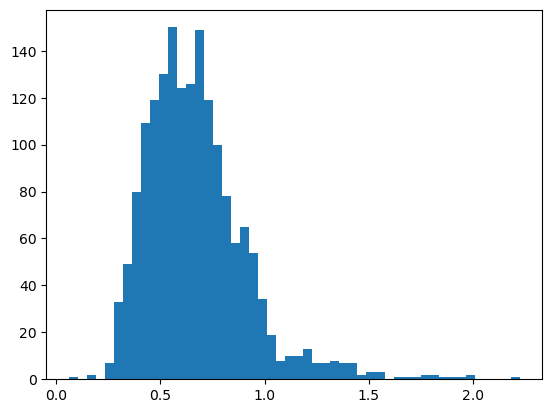

In [15]:
import matplotlib.pyplot as plt
plt.hist(scores_list, bins=50)
plt.show()

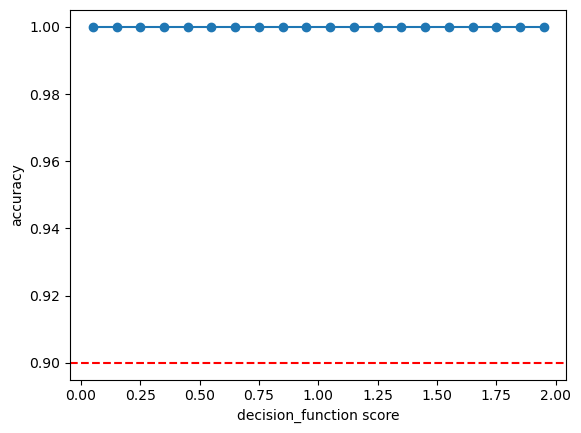

In [16]:
import matplotlib.pyplot as plt

scores_matrix = model.decision_function(x_train)
predictions = model.classes_[scores_matrix.argmax(axis=1)]
best_scores = scores_matrix.max(axis=1)

correct = (predictions == y_train)

# متوسط الـ accuracy لكل نطاق score
import numpy as np
bins = np.arange(0, 2.2, 0.1)
bin_indices = np.digitize(best_scores, bins)

accuracy_per_bin = []
bin_centers = []
for b in range(1, len(bins)):
    mask = bin_indices == b
    if mask.sum() > 0:
        accuracy_per_bin.append(correct[mask].mean())
        bin_centers.append((bins[b-1] + bins[b]) / 2)

plt.plot(bin_centers, accuracy_per_bin, marker='o')
plt.xlabel("decision_function score")
plt.ylabel("accuracy")
plt.axhline(0.9, color='red', linestyle='--')  # مثال: نفسك accuracy 90%+
plt.show()